# 00 KPI Engineering
Create all required KPIs, bins, quality checks, summaries, and exports.

In [1]:
import warnings
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils" / "utils.py").exists():
    if (PROJECT_ROOT / "notebooks" / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT / "notebooks"
    elif (PROJECT_ROOT.parent / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils.utils import ensure_project_dirs, load_raw_dataset, clean_dataset, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR
from utils.features import engineer_kpis, build_post_feature_sets, aggregate_business_features
from utils.evaluation import regression_metrics, rank_models
from utils.visualization import set_plot_style, save_figure

set_plot_style()
ensure_project_dirs()
RAW_DATA_PATH = Path(r"C:\univ\Data mining\Project\synthetic_generator\synthetic_social_media_posts.csv")
if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH = PROJECT_ROOT / "synthetic_generator" / "synthetic_social_media_posts.csv"
KPI_PATH = PROCESSED_DIR / "kpi_dataset.csv"

## Load and Clean Data

In [2]:
raw_df = load_raw_dataset(RAW_DATA_PATH)
clean_df = clean_dataset(raw_df)
print("Raw:", raw_df.shape, "Clean:", clean_df.shape)

Raw: (1000, 23) Clean: (1000, 23)


## Engineer KPIs and Validate Division Safety

In [3]:
df = engineer_kpis(clean_df)
rate_cols = ["engagement_rate", "like_rate", "comment_rate", "view_rate", "view_engagement_rate"]
invalid = {c: int(np.isinf(df[c]).sum() + df[c].isna().sum()) for c in rate_cols}
print("Invalid rate values:", invalid)
print("followers_count==0:", int((df["followers_count"] == 0).sum()))
print("views_count==0:", int((df["views_count"] == 0).sum()))
display(df.head())

Invalid rate values: {'engagement_rate': 0, 'like_rate': 0, 'comment_rate': 0, 'view_rate': 0, 'view_engagement_rate': 0}
followers_count==0: 0
views_count==0: 0


,business_name,sector,followers_count,post_date,posting_hour,day_of_week,month,post_type,caption_text,caption_length,...,is_reel,posting_time_bin,caption_length_bin,hashtags_count_bin,emoji_count_bin,engagement_level,business_size_bin,high_engagement,high_view_rate,high_comment_rate
0,Ramallah Care Pharmacy,pharmacy,13666,2025-12-16,22,Tuesday,12,carousel,صحتك بتهمنا Swipe وشوفوا الباقي. موجودين في Ra...,109,...,0,night,medium,few,none,low,large,0,0,0
1,Nablus Bites,restaurant,12838,2025-10-18,20,Saturday,10,video,اليوم عنا أكل طيب فيديو جديد. احنا جاهزين احجز...,78,...,0,evening,medium,few,none,medium,medium,0,0,0
2,Al Amal Dental,clinic,4652,2025-01-17,21,Friday,1,carousel,صحتكم أولويتنا سوايب وشوفوا التفاصيل. شو رأيكم...,142,...,0,night,long,few,few,low,small,0,0,0
3,Hebron Study Hub,education_center,26289,2025-03-27,20,Thursday,3,reel,استنونا بدورة جديدة شوفوا الريل. زورونا بفرعنا...,90,...,1,evening,medium,few,few,high,large,1,1,1
4,Bethlehem Brew Bar,cafe,2210,2025-11-01,22,Saturday,11,image,أجواء ولا أروع صورة جديدة. أهلا بالناس الحلوة ...,72,...,0,night,medium,few,none,medium,small,0,0,0


## Summary Tables and Exports

,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
2,cafe,94,748.872340,0.200186,1.697327,0.016266
0,bakery,87,628.609195,0.169791,1.305431,0.013931
8,restaurant,100,1272.370000,0.156801,1.395919,0.012776
9,store,124,4164.427419,0.140456,1.129093,0.012736
1,beauty_salon,76,667.815789,0.136087,1.272069,0.012155
6,gym,76,391.078947,0.124127,1.145004,0.011194
4,education_center,104,1567.028846,0.122962,1.324482,0.011239
5,electronics_store,127,5263.251969,0.120778,1.141459,0.009751
3,clinic,102,1143.754902,0.093695,1.240404,0.007884
7,pharmacy,110,812.009091,0.085343,1.165130,0.006401


,business_name,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
28,Qahwa Al-Quds,cafe,20,649.000000,0.231159,1.943234,0.019522
26,Nablus Sweet Oven,bakery,20,409.550000,0.227067,1.470653,0.020437
33,Ramallah Roastery,cafe,26,1320.730769,0.201025,1.850961,0.016016
4,Bethlehem Brew Bar,cafe,27,436.296296,0.195922,1.460202,0.015227
39,Tulkarm Streetwear,store,31,6418.967742,0.187580,1.456074,0.015698
22,Nablus Coffee Corner,cafe,21,537.857143,0.175132,1.577791,0.014809
34,Saj & Manakish House,bakery,19,1684.789474,0.174206,1.564093,0.013358
19,Laila Hair & Nails,beauty_salon,18,519.055556,0.172460,1.442218,0.017070
20,Nablus Bites,restaurant,30,2189.133333,0.172045,1.427922,0.012899
1,Al Balad Grill,restaurant,27,1241.555556,0.165165,1.456613,0.012499


,post_type,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
2,reel,314,3273.417197,0.237422,2.284067,0.019466
3,video,107,1832.037383,0.150798,1.419955,0.012714
0,carousel,206,1342.242718,0.091936,0.874086,0.008621
1,image,373,1035.361930,0.064099,0.602202,0.005467


,week,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
5,6,17,4184.882353,0.207416,1.769261,0.016543
48,49,16,2999.312500,0.203265,1.757185,0.014151
15,16,18,2680.833333,0.200712,1.471310,0.015980
46,47,16,1688.875000,0.188682,1.761912,0.014620
39,40,18,3752.444444,0.181550,1.664593,0.013662
26,27,26,2274.153846,0.179791,1.623862,0.018084
40,41,19,1825.210526,0.177488,1.502257,0.017125
28,29,15,2031.933333,0.175286,1.823230,0.015846
42,43,19,2124.578947,0.174444,1.636319,0.013650
45,46,18,3781.222222,0.172641,1.288603,0.013820


,month,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
10,11,81,2514.111111,0.162785,1.490641,0.013213
6,7,78,2390.794872,0.158728,1.441293,0.015255
11,12,97,1748.319588,0.152220,1.451962,0.012173
9,10,87,2117.275862,0.152152,1.386928,0.012463
3,4,74,1682.405405,0.141866,1.221412,0.012106
1,2,84,2300.892857,0.135215,1.371336,0.011162
5,6,89,1631.651685,0.123870,1.105135,0.010192
2,3,86,1879.616279,0.123142,1.124711,0.010195
7,8,91,1307.208791,0.116627,1.128573,0.010276
4,5,87,1227.080460,0.115496,1.249855,0.009789


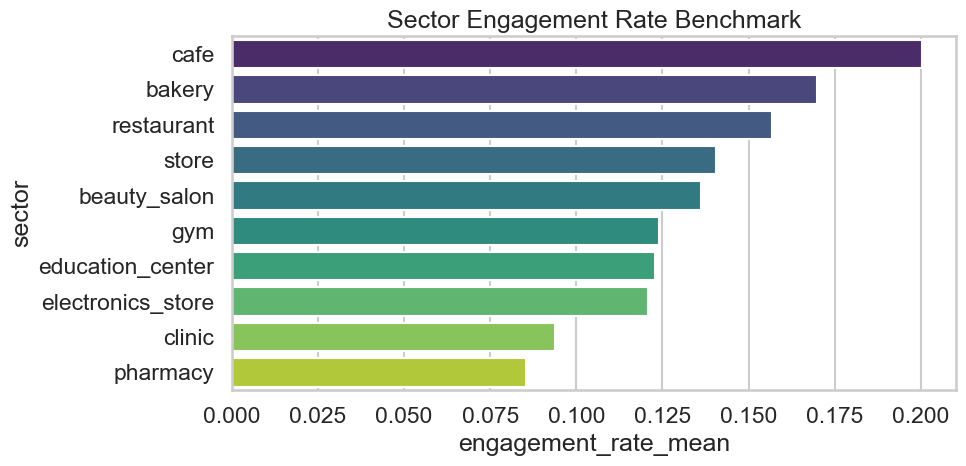

Insight: Top sector is cafe with engagement rate 0.2002.


In [4]:
summaries = {}
for key, grp in {
    "sector": ["sector"],
    "business": ["business_name", "sector"],
    "post_type": ["post_type"],
    "week": ["week"],
    "month": ["month"],
}.items():
    summaries[key] = df.groupby(grp, as_index=False).agg(
        posts_count=("business_name", "size"),
        engagement_mean=("engagement", "mean"),
        engagement_rate_mean=("engagement_rate", "mean"),
        view_rate_mean=("view_rate", "mean"),
        comment_rate_mean=("comment_rate", "mean"),
    ).sort_values("engagement_rate_mean", ascending=False)
    display(summaries[key].head(10))

df.to_csv(PROCESSED_DIR / "kpi_dataset.csv", index=False)
for k, v in summaries.items():
    v.to_csv(REPORTS_DIR / f"kpi_summary_{k}.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = summaries["sector"].head(15)
sns.barplot(data=plot_df, x="engagement_rate_mean", y="sector", ax=ax, palette="viridis")
ax.set_title("Sector Engagement Rate Benchmark")
save_figure(fig, FIGURES_DIR, "kpi_sector_engagement_rate.png")
plt.show()

top_sector = summaries["sector"].iloc[0]
print(f"Insight: Top sector is {top_sector['sector']} with engagement rate {top_sector['engagement_rate_mean']:.4f}.")